# Geneset / Pathway Activity

Consolidated notebook for the 6-step pipeline:

1. Load an `adata` (single-cell or metacell; male, female, or full)
2. Build a geneset of interest (custom gene list, or one/more GMT files) and report overlap with `adata.var_names`
3. Score each cell with `decoupler.mt.aucell`
4. Cliff's delta table between the two groups (CSV only)
5. Violin–box plot of the score per group, annotated with the Cliff's δ
6. Driver genes per group via Spearman correlation → heatmap

All functions live in `pygenelab.geneset_activity`. To switch dataset or pathway: uncomment one option in the **ADATA** cell and one in the **GENESET** cell, then run the rest.

In [25]:
palette = {
    "Con_F":    "#F71480",
    "SKM-KO_F": "#FA98C7",
    "Con_M":    "#0000C0",
    "SKM-KO_M": "#90BFF9",
}

In [26]:
import importlib
import pygenelab.geneset_activity
importlib.reload(pygenelab.geneset_activity)   # pull in the new functions
import pygenelab
importlib.reload(pygenelab)                    # re-run `from .geneset_activity import *`
import pygenelab as pgl

for fn in ("club_geneset_by_clean_label", "metab_directions_from_csv",
            "plot_score_grid_by_celltype"):
    assert hasattr(pgl, fn), f"missing {fn} — file: {pgl.geneset_activity.__file__}"
print("OK — loaded from:", pgl.geneset_activity.__file__)

OK — loaded from: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/pygenelab/geneset_activity.py


## Cell A — pick an `adata` input

In [27]:
def _seacell_y_to_condition(ad):
    ad.obs["condition"] = ad.obs["y"].apply(lambda x: "WT" if x == 0 else "KO").astype("category")

# per-sex WT/KO palettes derived from the top-level `palette` dict
# (Con_* → WT, SKM-KO_* → KO)
PALETTE_F = {"WT": palette["Con_F"], "KO": palette["SKM-KO_F"]}
PALETTE_M = {"WT": palette["Con_M"], "KO": palette["SKM-KO_M"]}
PALETTE_Both = {**PALETTE_F, **PALETTE_M}  # for combined

# --- Mice female metacells, FastIIB / FastIIX (WT vs KO) ---
# ADATA_CFG = (
#     "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad",
#     # PSC: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad
#     "condition", "WT", "KO",
#     PALETTE_F,
#     "mice",
#     _seacell_y_to_condition,
#     None, None,  # metacells: no cell-type subsetting
# )

# --- Mice female single-cell, all cell types (WT vs KO) — has 'condition' already ---
ADATA_CFG = (
    "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_male.h5ad",
    # PSC: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad
    "condition", "WT", "KO",
    PALETTE_M,
    "mice",
    None,
    "re_annot", ["Fast IIX", "Fast IIB"],  # subset to one or more cell types; set both to None to keep all
)

# --- Mice male single-cell, all cell types (WT vs KO) ---
# ADATA_CFG = (
#     "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_male.h5ad",
#     "condition", "WT", "KO",
#     PALETTE_M,
#     "mice",
#     None,
#     "re_annot", ["Fast IIB"],
# )

# --- Human female single-cell myofibers ---
# ADATA_CFG = (
#     "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad",
#     "sample", "OM6", "OM9",
#     {"OM6": "#B6D7A8", "OM9": "#F08080"},
#     "human",
#     None,
#     "cell_type", None,  # set to a list of labels (e.g. ["FastIIB"]) to subset
# )

In [17]:
adata_path, GROUP_COL, GROUP_1, GROUP_2, PALETTE, GENE_ORIGIN, PREP, CELLTYPE_COL, CELLTYPES = ADATA_CFG
GROUPS = (GROUP_1, GROUP_2)

adata = pgl.load_adata(adata_path)
if PREP is not None:
    PREP(adata)

if CELLTYPE_COL is not None and CELLTYPES is not None:
    if CELLTYPE_COL not in adata.obs.columns:
        raise KeyError(
            f"celltype_col '{CELLTYPE_COL}' not in adata.obs. "
            f"Available columns: {list(adata.obs.columns)}"
        )
    available = set(adata.obs[CELLTYPE_COL].astype(str).unique())
    missing = [c for c in CELLTYPES if c not in available]
    if missing:
        raise ValueError(
            f"Cell types {missing} not found in adata.obs['{CELLTYPE_COL}']. "
            f"Available: {sorted(available)}"
        )
    n_before = adata.n_obs
    adata = adata[adata.obs[CELLTYPE_COL].astype(str).isin(CELLTYPES)].copy()
    print(f"Subset on {CELLTYPE_COL} ∈ {CELLTYPES}: {n_before} → {adata.n_obs} cells")

print(adata)
print(f"\n{GROUP_COL} counts:\n{adata.obs[GROUP_COL].value_counts()}")

Subset on re_annot ∈ ['Fast IIX', 'Fast IIB']: 44171 → 32237 cells
AnnData object with n_obs × n_vars = 32237 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI', 're_annot'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 

## Cell B — pick a geneset / pathway

Three flavors: a custom hardcoded list, a single pathway from a GMT, or multiple GMTs stacked.
Uncomment exactly one block. `PATHWAY_NAME` is what becomes the `obs` column after AUCell scoring.

In [ ]:
# --- Option 1: custom hardcoded gene list (atrophy) ---
# CUSTOM_ATROPHY_GENES = [
#     "UBB", "UBC", "FBXO32", "TRIM63", "MDM2", "FBXO30", "CAMK2B", "TIE1",
#     "PSMA1", "PSMA2", "PSMA3", "PSMA4", "PSMA5", "PSMA6", "PSMA7",
#     "PSMB1", "PSMB2", "PSMB3", "PSMB4", "FBXO21", "FBXO31", "NEDD4",
#     "UBE2B", "UBE2G1", "UBE2J1", "CTSL", "CTSV", "BNIP3", "DEPP1",
#     "GABARAPL1", "MAP1LC3", "RETREG1", "SQSTM1", "CAPN1", "CAPN2",
#     "ATF4", "FOXO1", "FOXO3A", "HDAC9", "RUNX1", "AMPD3", "CHRNA1",
#     "CDKN1A",
# ]
# PATHWAY_NAME = "CUSTOM_ATROPHY"
# geneset_df = pgl.geneset_from_list(
#     CUSTOM_ATROPHY_GENES,
#     name=PATHWAY_NAME,
#     gene_origin=GENE_ORIGIN,
# )

# --- Option 2: one pathway from a mouse MSigDB GMT ---
# MICE_MSIGDB = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
# PATHWAY_NAME = "GOBP_PYRUVATE_METABOLIC_PROCESS"
# geneset_df = pgl.geneset_from_gmt(
#     gmt_path=MICE_MSIGDB,
#     include_pathways=[PATHWAY_NAME],
#     gene_origin=GENE_ORIGIN,
# )

# --- Option 3: senescence (SAUL SEN-MAYO UP) ---
# SEN_MAYO_GMT = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt"
# PATHWAY_NAME = "SAUL_SEN_MAYO_UP_IN_SEN"
# geneset_df = pgl.geneset_from_gmt(
#     gmt_path=SEN_MAYO_GMT,
#     include_pathways=[PATHWAY_NAME],
#     gene_origin=GENE_ORIGIN,
# )

# --- Option 4: multiple human metabolic pathways (one obs column per pathway) ---
METABOLIC_GMTS = [
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt",
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt",
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt",
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt",
    "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt",
]
PATHWAY_NAME = None  # use first computed pathway for downstream single-score plots
geneset_df = pgl.geneset_from_gmts(METABOLIC_GMTS, gene_origin=GENE_ORIGIN)

#--- Option 5: DNA damage / repair (mouse) ---
# DNA_DAMAGE_GMTS = [
#     "/ix/djishnu/Akanksha/datasets/gene_sets/gene_sets/mouse/dna_damage/GOBP_DNA_DAMAGE_RESPONSE.v2026.1.Mm.gmt",
# ]
# PATHWAY_NAME = "GOBP_DNA_DAMAGE_RESPONSE"
# geneset_df = pgl.geneset_from_gmts(DNA_DAMAGE_GMTS, gene_origin=GENE_ORIGIN)

# 

print(geneset_df.head())
print(f"\nGeneset entries: {len(geneset_df)}  |  unique pathways: {geneset_df['source'].nunique()}")

## Output directory

In [ ]:
OUTPUT_DIR = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output"
) / (PATHWAY_NAME or geneset_df['source'].iloc[0])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ADATA_NAME = Path(adata_path).stem
if CELLTYPE_COL is not None and CELLTYPES is not None:
    ADATA_NAME = f"{ADATA_NAME}__{'_'.join(CELLTYPES)}"

print(OUTPUT_DIR)
print(f"ADATA_NAME = {ADATA_NAME}")

## Step 2 — geneset ↔ adata overlap

In [ ]:
overlap = pgl.report_geneset_overlap(
    geneset_df=geneset_df,
    adata=adata,
    pathway_name=PATHWAY_NAME,
)

## Step 3 — AUCell scoring

In [ ]:
pathways = pgl.score_geneset_aucell(
    adata=adata,
    geneset_df=geneset_df,
    raw=False,
    tmin=None,  # set to e.g. 4 if the pathway has very few mapped genes
)
if PATHWAY_NAME is None:
    PATHWAY_NAME = pathways[0]
SCORE_COL = PATHWAY_NAME
print(f"Scored pathways: {pathways}\nUsing SCORE_COL = {SCORE_COL}")

## Step 4 — Cliff's delta between the two groups

Computed first so the violin plot below can be annotated with the δ value. CSV is written to the output folder; no image is produced — the table is shown inline.

In [ ]:
cliffs_df = pgl.cliffs_delta_table(
    adata=adata,
    score_cols=pathways,
    group_col=GROUP_COL,
    group1=GROUP_1,
    group2=GROUP_2,
    output_csv=OUTPUT_DIR / f"{ADATA_NAME}_cliffs_delta.csv",
)

# report cliff's delta as magnitude + direction (the sign on cliffs_delta
# just encodes which group is higher; abs_cliffs_delta + higher_group is
# the more readable form for the violin annotation)
_row = cliffs_df.loc[cliffs_df["score_col"] == SCORE_COL].iloc[0]
ABS_DELTA = float(_row["abs_cliffs_delta"])
HIGHER = _row["higher_group"]
DELTA_LABEL = f"Cliff's δ = {ABS_DELTA:.3f} (higher in {HIGHER})"
print(DELTA_LABEL)
cliffs_df

## Step 5 — violin–box of the score across groups

Annotated with the Cliff's δ value from Step 4. Significance is shown as asterisks only (no numeric p-value).

In [ ]:
plot_df, violin_fig = pgl.plot_score_by_group(
    adata=adata,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    palette=PALETTE,
    group_order=list(GROUPS),
    title=SCORE_COL,
    show_scatter=False,   # set True to overlay per-cell dots on the violins
    show_pvalue=False,    # asterisks only, no numeric p-value
    delta_label=DELTA_LABEL,
    group_spacing=0.8,
    ylim=None
)
violin_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_violin.svg", bbox_inches="tight")
violin_fig

## Step 6 — driver genes per group + heatmap

Spearman correlation between every pathway gene and the AUCell score, computed independently per group.

In [ ]:
ranked_dfs = pgl.compute_driver_genes_per_group(
    adata=adata,
    geneset=geneset_df,
    score_col=SCORE_COL,
    group_col=GROUP_COL,
    groups=list(GROUPS),
)
heatmap_df, heatmap_fig, _ = pgl.plot_driver_heatmap(
    ranked_dfs=ranked_dfs,
    top_n=20,
    title=f"Driver Genes — {SCORE_COL}",
)
heatmap_fig.savefig(OUTPUT_DIR / f"{ADATA_NAME}_drivers_heatmap.svg", bbox_inches="tight")
heatmap_fig

# Metabolic pathways — Fast IIX vs Fast IIB side by side

Self-contained section (independent of Cells A/B above). Pick a sex and a
heatmap **direction** (`Up`/`Down`), load that sex's **enriched metabolism
geneset** — the decoupler-format CSV written by Step 9 of
`DEG_Functional_Enrichment.ipynb` (`msigdb metabolism enriched pathways
mice/metabolism_enriched_pathways_<sex>.csv`, columns `source,target,direction`)
— then score the canonical male/female single-cell adata and visualise the
WT-vs-KO score for **Fast IIX** and **Fast IIB**.

Two figures:
1. **Single-pathway focus** (`MET_SCORE_COL`): Fast IIX (left) and Fast IIB
   (right) as two panels, shared y-axis, each annotated with its own Cliff's δ.
2. **Direction grid**: every cleaned pathway in the selected Step 9 heatmap
   panel (e.g. all `Up` pathways for the male) becomes one **row**; columns are
   Fast IIX | Fast IIB; each cell is the WT-vs-KO violin-box with its own
   Cliff's δ + significance asterisks. y-axis shared per pathway row.

The CSV `source` labels are the raw MSigDB names (`HALLMARK_FATTY_ACID_METABOLISM`,
`REACTOME_METABOLISM_OF_CARBOHYDRATES`, `WP_PURINE_METABOLISM`, …). Before
scoring they are cleaned with `pgl.club_geneset_by_clean_label` — the same
DB-prefix + `metabolism`-boilerplate stripping that Step 9 uses for the heatmap
y-ticks — so the scored pathways match the pathways plotted in the heatmap. Any
sources that simplify to the **same** cleaned label have their genes **clubbed
(unioned, deduplicated)** into a single geneset. The Up/Down direction is read
from the CSV's `direction` column (`pgl.metab_directions_from_csv`), keyed by
the cleaned label, so the grid shows exactly the pathways in that heatmap panel.

**Config** — all run knobs live in the `MET_CFG` tuple at the top of the next
cell (mirrors the `ADATA_CFG` style of Cell A):
`MET_CFG = (sex, direction, focus_pathway)`
- `sex`: `"F"` or `"M"`
- `direction`: `"Up"` or `"Down"` — which Step 9 heatmap panel to plot
- `focus_pathway`: one **cleaned** label for the single-pathway focus figure
  (e.g. `"Fatty Acid"`); `None` → first pathway in the selected direction.

Prereqs: run the `palette` cell, the imports cell, and the **Cell A** cell
(which defines `PALETTE_F` / `PALETTE_M`) first; and **(re-)run Step 9** of the
DEG enrichment notebook so the CSVs carry the `direction` column.

In [35]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CONFIG — pick the sex + heatmap-direction panel to plot (edit here)   ║
# ╚══════════════════════════════════════════════════════════════════════╝
# Mirrors the ADATA_CFG tuple style of Cell A: one place to set the knobs.
#   sex           : "F" or "M"
#   direction     : "Up" or "Down" — which Step 9 heatmap panel to plot
#   focus_pathway : cleaned label for the single-pathway focus plot
#                   (e.g. "Fatty Acid"); None -> first pathway in `direction`
MET_CFG = (
    "M",    # sex
    "Up",   # direction
    None,   # focus_pathway
)

MET_SEX, MET_DIRECTION, MET_FOCUS_PATHWAY = MET_CFG
if MET_SEX not in ("F", "M"):
    raise ValueError(f"MET_SEX must be 'F' or 'M', got {MET_SEX!r}")
if MET_DIRECTION not in ("Up", "Down"):
    raise ValueError(f"MET_DIRECTION must be 'Up' or 'Down', got {MET_DIRECTION!r}")

# ── fixed lookups (rarely change) ────────────────────────────────────────
# canonical single-cell adata per sex (WT vs KO, all cell types)
MET_ADATA_PATHS = {
    "F": "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_female.h5ad",
    "M": "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot_male.h5ad",
}

# metabolic geneset per sex — decoupler-format CSVs (source, target, direction)
# written by Step 9 of DEG_Functional_Enrichment.ipynb (the enriched metabolism
# pathways, mice gene symbols, + the Up/Down heatmap panel each pathway lands
# in). One obs column per pathway after scoring.
MET_ENRICHED_DIR = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code"
    "/py_scripts/3_geneset_scores/msigdb metabolism enriched pathways mice"
)
MET_GENESET_CSVS = {
    "F": MET_ENRICHED_DIR / "metabolism_enriched_pathways_F.csv",
    "M": MET_ENRICHED_DIR / "metabolism_enriched_pathways_M.csv",
}

# WT vs KO contrast and the two fast cell types (left -> right panel order)
MET_GROUP_COL, MET_GROUP_1, MET_GROUP_2 = "condition", "WT", "KO"
MET_CELLTYPE_COL = "re_annot"
MET_CELLTYPES = ["Fast IIX", "Fast IIB"]
MET_PALETTE = PALETTE_F if MET_SEX == "F" else PALETTE_M  # from Cell A

# ── resolve the selected config ──────────────────────────────────────────
met_adata_path = MET_ADATA_PATHS[MET_SEX]
met_geneset_csv = MET_GENESET_CSVS[MET_SEX]
if not Path(met_geneset_csv).exists():
    raise FileNotFoundError(
        f"No enriched-pathway CSV at {met_geneset_csv}.\n"
        "Run Step 9 of DEG_Functional_Enrichment.ipynb first to generate it."
    )

print(f"sex={MET_SEX}  direction={MET_DIRECTION}  focus={MET_FOCUS_PATHWAY}")
print(f"adata: {Path(met_adata_path).name}")
print(f"geneset CSV: {met_geneset_csv}")

sex=M  direction=Up  focus=None
adata: adata_harmony_v2_re_annot_male.h5ad
geneset CSV: /ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/msigdb metabolism enriched pathways mice/metabolism_enriched_pathways_M.csv


In [36]:
# load the canonical sex adata, keep BOTH fast cell types, then AUCell-score.
# AUCell ranks genes within each cell independently, so scoring the two
# cell types together is equivalent to scoring them separately.
met_adata = pgl.load_adata(met_adata_path)
met_adata = met_adata[
    met_adata.obs[MET_CELLTYPE_COL].astype(str).isin(MET_CELLTYPES)
].copy()
print("cells per (cell type, condition):")
print(met_adata.obs.groupby([MET_CELLTYPE_COL, MET_GROUP_COL]).size())

# enriched metabolism geneset (decoupler format, already mice gene symbols).
# Strip the DB prefix (WP / REACTOME / HALLMARK) + 'metabolism' boilerplate from
# every `source` label and club the genes per cleaned pathway (sources that
# simplify to the same label have their genes unioned) — exactly as Step 9's
# `_clean_metab_label` does for the heatmap y-ticks. The pathways plotted in the
# Step 9 heatmap therefore become the input to this scoring, and the scored obs
# columns read 'Fatty Acid', 'Purine', ... instead of 'HALLMARK_FATTY_ACID_METABOLISM'.
met_geneset_raw = pgl.geneset_from_csv(met_geneset_csv)
met_geneset_df = pgl.club_geneset_by_clean_label(met_geneset_raw)
print(
    f"\n{met_geneset_raw['source'].nunique()} raw sources "
    f"-> {met_geneset_df['source'].nunique()} cleaned metabolism pathways:"
)
for s in met_geneset_df["source"].unique():
    n = met_geneset_df.loc[met_geneset_df["source"] == s, "target"].nunique()
    print(f"  - {s} ({n} genes)")
pgl.report_geneset_overlap(met_geneset_df, met_adata)

met_pathways = pgl.score_geneset_aucell(
    adata=met_adata,
    geneset_df=met_geneset_df,
    raw=False,
    tmin=None,   # set e.g. 4 if a pathway has very few mapped genes
)

# heatmap direction (Up / Down) per cleaned pathway, read from the CSV's
# `direction` column (written by Step 9). Keep only the pathways that were in
# the SELECTED panel (MET_DIRECTION) of the Step 9 heatmap for this sex — these
# are the rows of the grid below.
met_directions = pgl.metab_directions_from_csv(met_geneset_csv)
met_pathways_dir = [p for p in met_pathways if met_directions.get(p) == MET_DIRECTION]
print(f"\ndirection per pathway: {met_directions}")
print(f"{MET_DIRECTION}-panel pathways for {MET_SEX}: {met_pathways_dir}")

MET_SCORE_COL = MET_FOCUS_PATHWAY or (met_pathways_dir or met_pathways)[0]
print(f"single-pathway focus plot uses: {MET_SCORE_COL}")

/tmp/ipykernel_3834351/451411482.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(met_adata.obs.groupby([MET_CELLTYPE_COL, MET_GROUP_COL]).size())
2026-05-31 21:58:41 | [INFO] aucell - Running aucell
2026-05-31 21:58:41 | [INFO] Extracted omics mat with 32237 rows (observations) and 3000 columns (features)
2026-05-31 21:58:41 | [WARNING] 22 features of mat are empty, they will be removed
2026-05-31 21:58:41 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-31 21:58:41 | [INFO] Network has 127 unique features and 6 unique sources
2026-05-31 21:58:41 | [INFO] aucell - calculating 6 AUCs for 2978 targets across 32237 observations, categorizing features at rank=149


cells per (cell type, condition):
re_annot  condition
Fast IIB  KO           14008
          WT            8915
Fast IIX  KO            4392
          WT            4922
dtype: int64

6 raw sources -> 6 cleaned metabolism pathways:
  - Glucose (73 genes)
  - Glycogen (18 genes)
  - Carbohydrates (261 genes)
  - Purine (172 genes)
  - Fatty Acid (155 genes)
  - Xenobiotic (196 genes)
[geneset] 127/733 genes present in adata.var_names (606 missing)


  0%|          | 0/32237 [00:00<?, ?it/s]

2026-05-31 21:58:49 | [INFO] aucell - done



direction per pathway: {'Glucose': 'Up', 'Glycogen': 'Down', 'Carbohydrates': 'Up', 'Purine': 'Up', 'Fatty Acid': 'Up', 'Xenobiotic': 'Down'}
Up-panel pathways for M: ['Carbohydrates', 'Fatty Acid', 'Glucose', 'Purine']
single-pathway focus plot uses: Carbohydrates


/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/pygenelab/plotting.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/pygenelab/plotting.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/pygenelab/plotting.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysi

/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output/metabolism_grids/M_Up_FastIIX_FastIIB_metab_grid.png


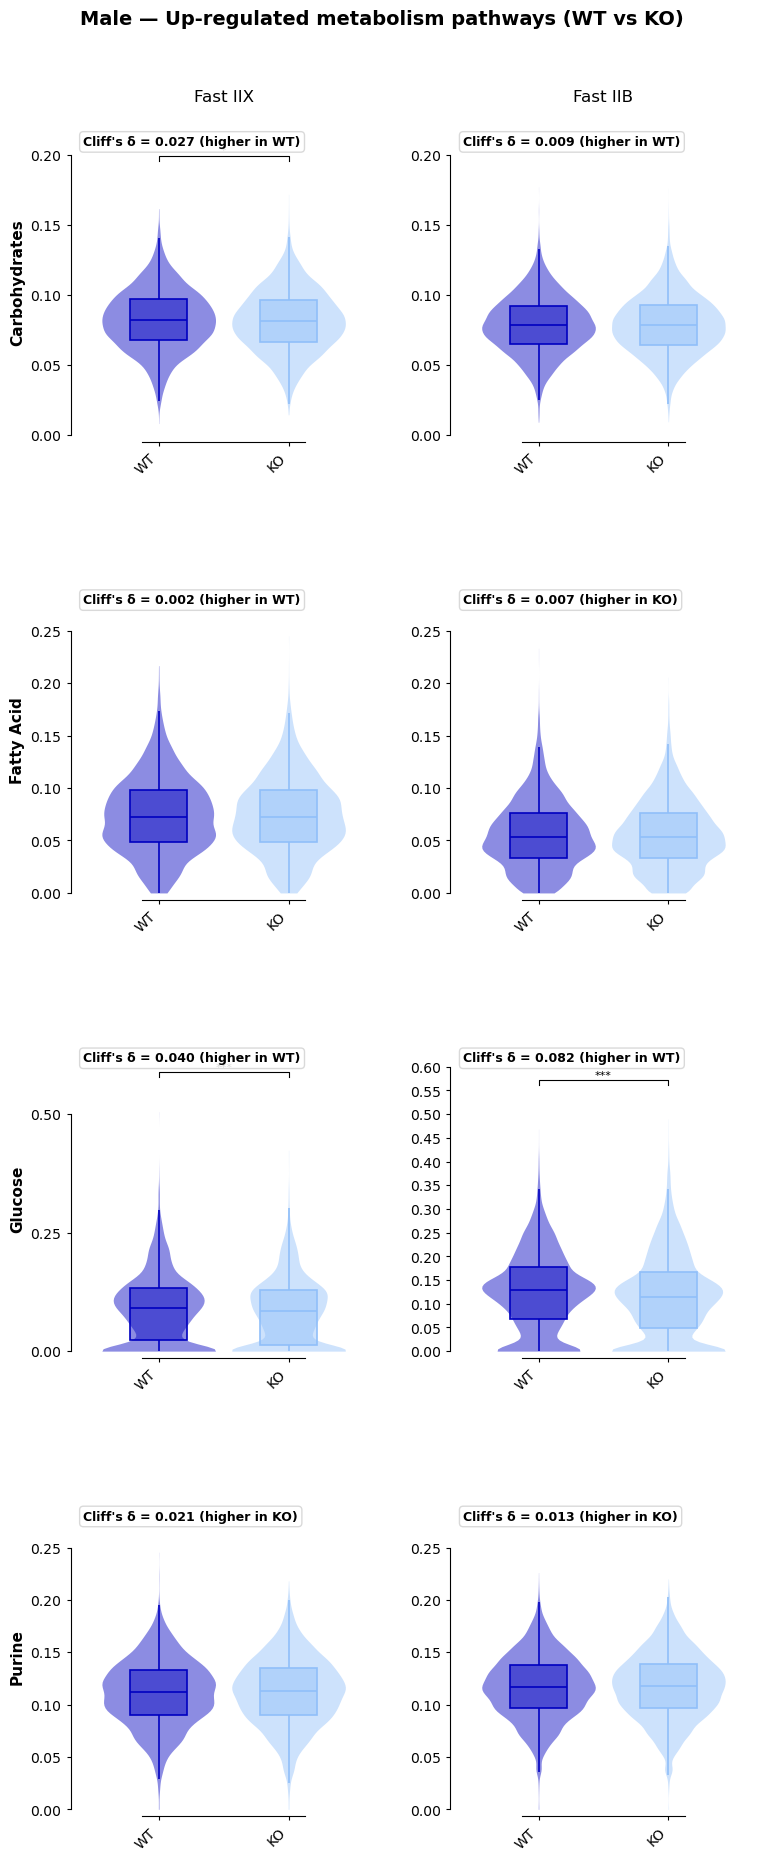

In [37]:
# ── grid: every <MET_DIRECTION> metabolism pathway as its own row ─────────
# One ROW per cleaned pathway enriched in the selected Step 9 heatmap panel
# (Up or Down) for this sex; columns = Fast IIX | Fast IIB. Each panel is the
# WT-vs-KO violin-box for that (pathway, cell type), annotated with its own
# Cliff's δ + significance asterisks. y-axis is shared across the two cell
# types within a pathway row (AUCell magnitudes differ between genesets).
if not met_pathways_dir:
    raise ValueError(
        f"No {MET_DIRECTION} pathways for sex={MET_SEX}. "
        f"Directions present: {sorted(set(met_directions.values()))}. "
        "Flip MET_DIRECTION, or re-run Step 9 of DEG_Functional_Enrichment.ipynb."
    )

met_grid_fig, met_grid_results = pgl.plot_score_grid_by_celltype(
    adata=met_adata,
    score_cols=met_pathways_dir,           # one row per pathway, in this order
    group_col=MET_GROUP_COL,
    group1=MET_GROUP_1,
    group2=MET_GROUP_2,
    celltype_col=MET_CELLTYPE_COL,
    celltypes=MET_CELLTYPES,               # ["Fast IIX", "Fast IIB"] -> columns
    palette=MET_PALETTE,
    suptitle=(
        f"{'Female' if MET_SEX == 'F' else 'Male'} — "
        f"{MET_DIRECTION}-regulated metabolism pathways (WT vs KO)"
    ),
    show_scatter=False,
    show_pvalue=False,                     # asterisks only on the significance bars
    share_y_per_pathway=True,
)

met_grid_dir = Path(
    "/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts/3_geneset_scores/Output"
) / "metabolism_grids"
met_grid_dir.mkdir(parents=True, exist_ok=True)
met_grid_stem = f"{MET_SEX}_{MET_DIRECTION}_FastIIX_FastIIB_metab_grid"
met_grid_fig.savefig(met_grid_dir / f"{met_grid_stem}.svg", bbox_inches="tight")
met_grid_fig.savefig(met_grid_dir / f"{met_grid_stem}.png", dpi=300, bbox_inches="tight")
print(met_grid_dir / f"{met_grid_stem}.png")
met_grid_fig